In [4]:
import pandas as pd
from pandas import Series, DataFrame

In [5]:
titanic_df=pd.read_csv(r'C:\Users\gridh\Downloads\train.csv')

In [6]:
titanic_df.head()
#name here is of no significance

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Effective data analysis begins with asking meaningful questions. For this dataset, we consider the following:

Who were the passengers on the Titanic? What were their ages, genders, and classes?

What decks were the passengers on, and how does that relate to their class?

Where did the passengers come from? Which cities did they embark from?

Who was alone, and who was with family aboard?

What factors influenced survival during the Titanic sinking?

These questions will guide our analysis and data manipulation

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

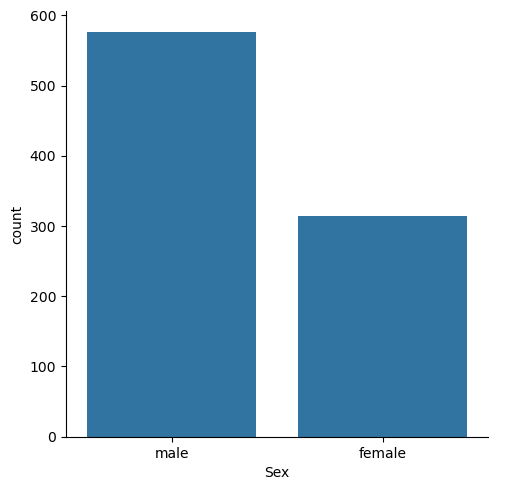

In [25]:
sns.catplot(x='Sex', kind='count', data=titanic_df)
plt.show()

Graph Analysis: Male, Female sex ratio

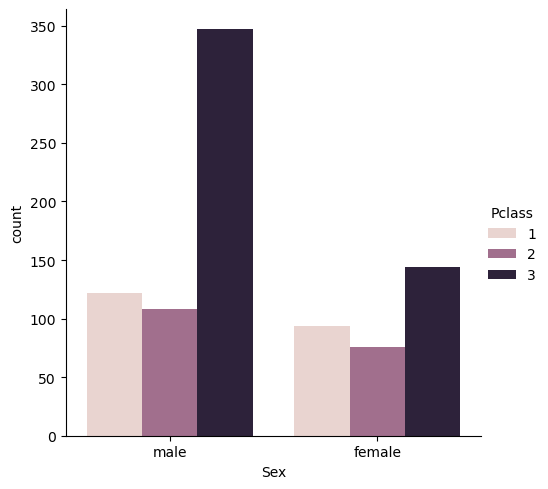

In [28]:
sns.catplot(x='Sex', data=titanic_df, hue='Pclass', kind='count')
plt.show()

Graph Analysis: Most third-class passengers were male, while female passengers were more evenly distributed across all classes.

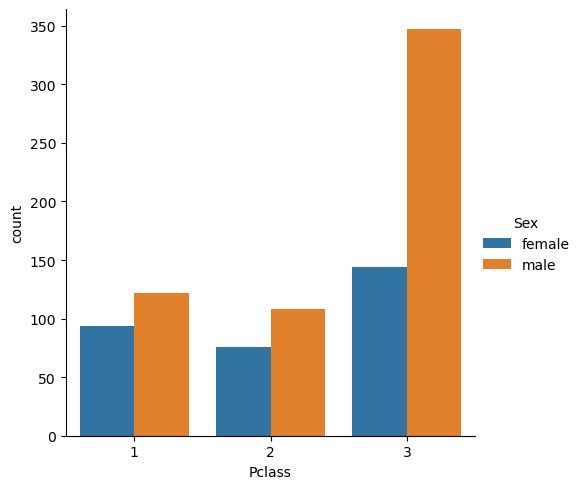

In [30]:
sns.catplot(x='Pclass', data=titanic_df, hue='Sex', kind='count')
plt.show()

Graph Analysis:The third class had the highest number of passengers, especially males, while female passengers were more evenly distributed across all classes.

In [53]:
def male_female_child(passenger):
    age,sex = passenger

    if age<18:
        return 'child'
    else:
        return sex

In [54]:
titanic_df['person']=titanic_df[['Age','Sex']].apply(male_female_child, axis=1)

In [39]:
titanic_df[0:10]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,person
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,male
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,female
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,female
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,male
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,male
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,male
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,child
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,female
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,child


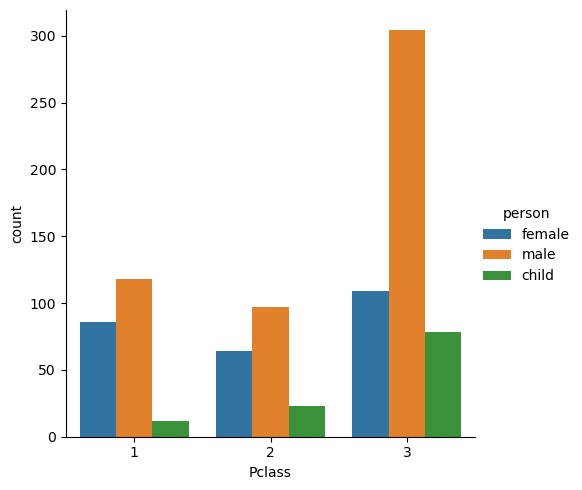

In [40]:
sns.catplot(x='Pclass', data=titanic_df, hue='person', kind='count')
plt.show()

Graph Analysis: Most children and males were in third class, while females were more evenly spread across all classes.

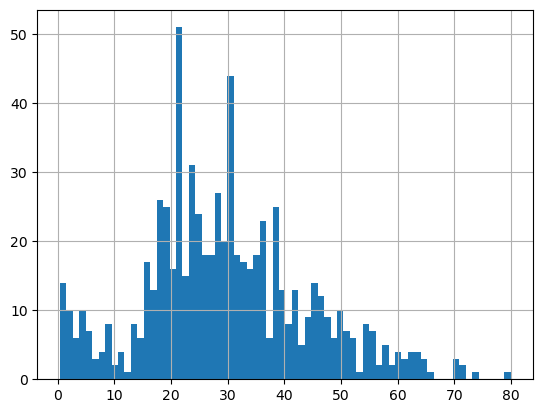

In [45]:
titanic_df['Age'].hist(bins=70)
plt.show()

Graph Analysis: Most passengers on the Titanic were between 20 and 30 years old, with very few older than 60.

In [46]:
titanic_df['Age'].mean()

np.float64(29.69911764705882)

In [47]:
titanic_df['person'].value_counts()

person
male      519
female    259
child     113
Name: count, dtype: int64

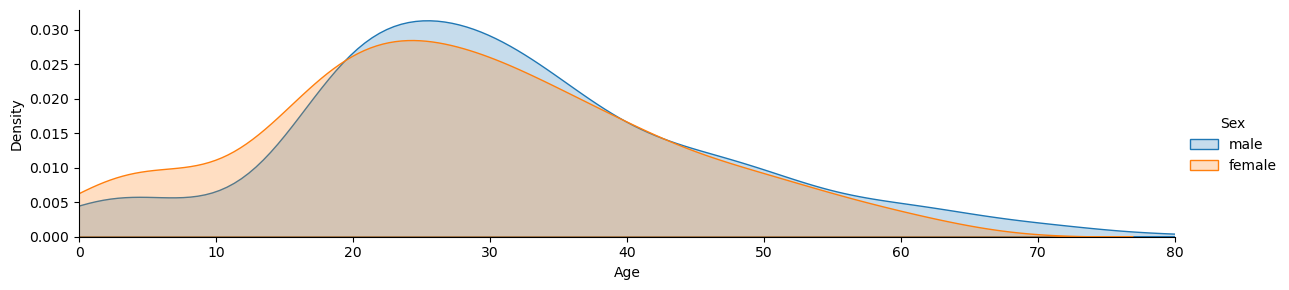

In [54]:
fig=sns.FacetGrid(titanic_df,hue='Sex',aspect=4)

fig.map(sns.kdeplot,'Age',fill=True)

oldest=titanic_df['Age'].max()

fig.set(xlim=(0,oldest))

fig.add_legend()

plt.show()

KDE (Kernel Density Estimate) plots show the probability density of a continuous variable — a smoothed version of a histogram — helping us understand the distribution shape and concentration of values. 
Graph Analysis: Most male and female passengers were aged between 20 and 35, with females having a slightly higher proportion in younger age groups.

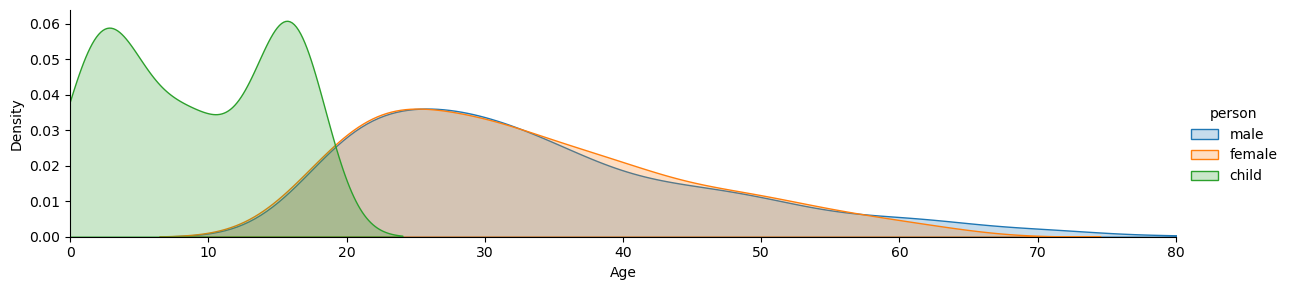

In [55]:
fig=sns.FacetGrid(titanic_df,hue='person',aspect=4)

fig.map(sns.kdeplot,'Age',fill=True)

oldest=titanic_df['Age'].max()

fig.set(xlim=(0,oldest))

fig.add_legend()

plt.show()

Graph Analysis: Children were mostly aged 0–12, while adults (male and female) peaked around 25–30 years, with similar age distributions but slightly higher concentration of younger females.

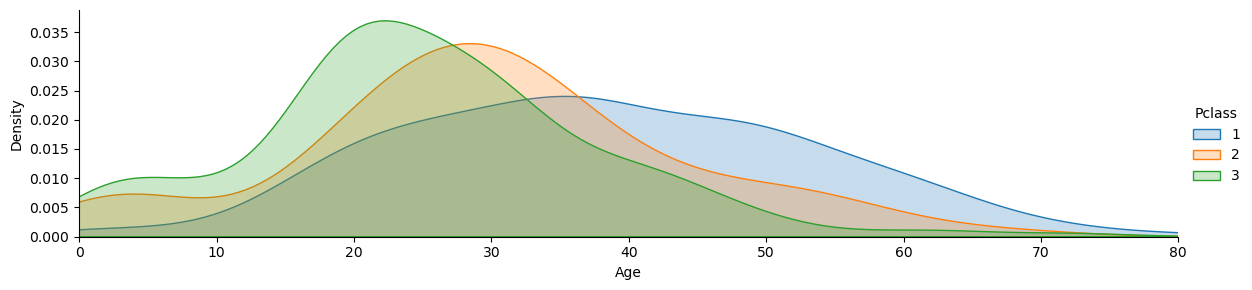

In [57]:
fig=sns.FacetGrid(titanic_df,hue='Pclass',aspect=4)

fig.map(sns.kdeplot,'Age',fill=True)

oldest=titanic_df['Age'].max()

fig.set(xlim=(0,oldest))

fig.add_legend()

plt.show()

In [62]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,person
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,male
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,female
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,female
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,male


In [61]:
deck=titanic_df['Cabin'].dropna()
deck.head()

1      C85
3     C123
6      E46
10      G6
11    C103
Name: Cabin, dtype: object

In [66]:
levels=[]
for level in deck:
    levels.append(level[0])

cabin_df=DataFrame(levels)
cabin_df.columns=['Cabin']
sns.catplot(x='Cabin',data=cabin_df,palette='winter',kind='count')


C:\Users\gridh\AppData\Local\Temp\ipykernel_24840\1957139040.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x='Cabin',data=cabin_df,palette='winter',kind='count')


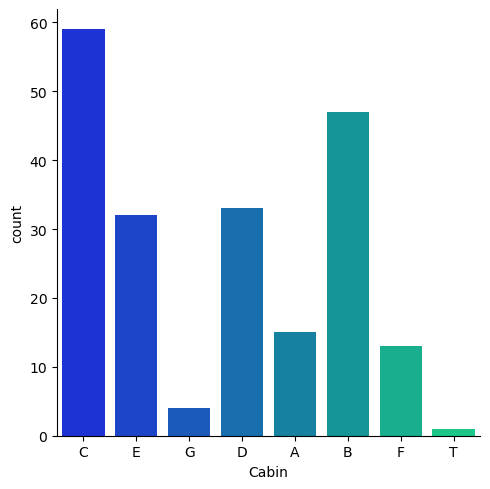

In [67]:
plt.show()

C:\Users\gridh\AppData\Local\Temp\ipykernel_24840\3496370044.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x='Cabin',data=cabin_df,palette='summer',order=sorted(cabin_df['Cabin'].unique()),kind='count')


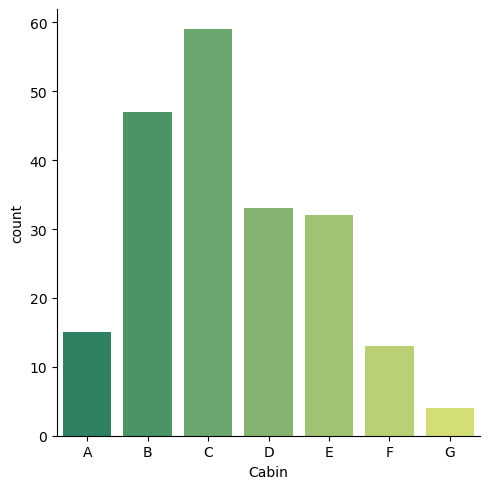

In [84]:
cabin_df=cabin_df[cabin_df.Cabin!='T']
sns.catplot(x='Cabin',data=cabin_df,palette='summer',order=sorted(cabin_df['Cabin'].unique()),kind='count')
plt.show()

In [90]:
sns.catplot(data=titanic_df,x='Embarked',hue='Pclass',kind='count')


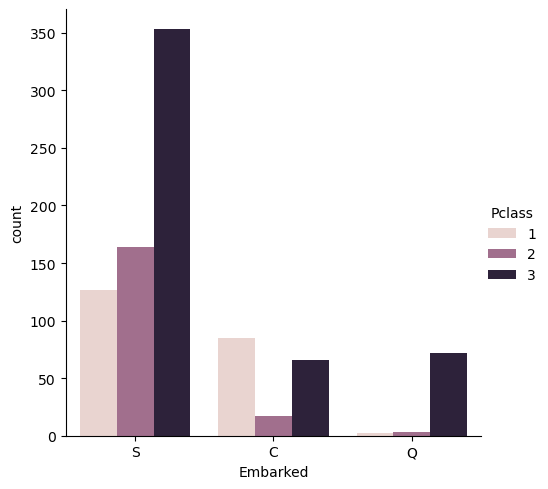

In [92]:
plt.show()

Ques: Who was alone and who was with family?

In [15]:
titanic_df['Has Family'] = ((titanic_df['SibSp'] > 0) | (titanic_df['Parch'] > 0)).map({True: 'Not Alone', False: 'Alone'})
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Has Family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Not Alone
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Not Alone
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Not Alone
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Alone
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Alone
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Alone
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Not Alone
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Alone


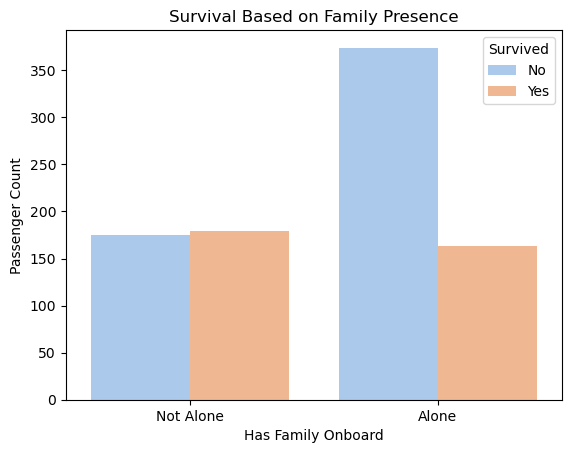

In [17]:
sns.countplot(data=titanic_df, x='Has Family', hue='Survived', palette='pastel')
plt.xlabel('Has Family Onboard')
plt.ylabel('Passenger Count')
plt.title('Survival Based on Family Presence')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

Now we answer the most awaited question: What factors influenced the difference between life and death

In [29]:
titanic_df['Survivor']=titanic_df.Survived.map({0:'no',1:'yes'})
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Has Family,Survivor
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Not Alone,no
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Not Alone,yes
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Alone,yes
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Not Alone,yes
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Alone,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Alone,no
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Alone,yes
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Not Alone,no
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Alone,yes


In [34]:
sns.countplot(x='Survivor',data=titanic_df,palette='Set1')

C:\Users\gridh\AppData\Local\Temp\ipykernel_6096\2742158052.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survivor',data=titanic_df,palette='Set1')


<Axes: xlabel='Survivor', ylabel='count'>

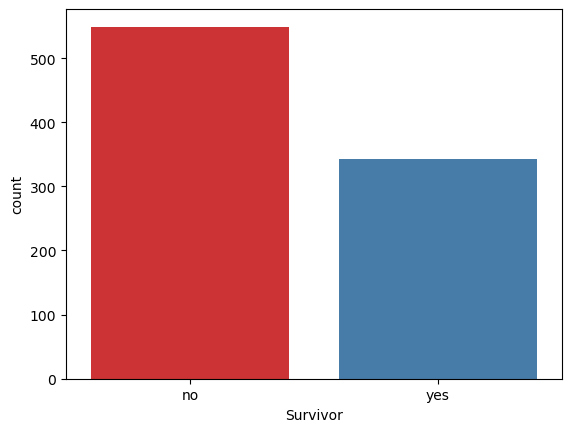

In [35]:
plt.show()

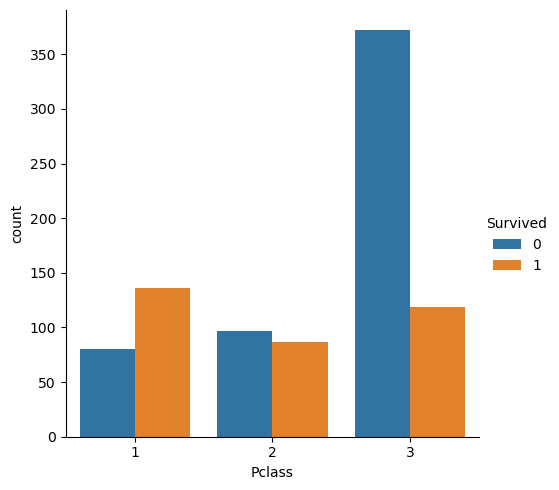

In [50]:
sns.catplot(x='Pclass',hue='Survived',data=titanic_df,kind='count')
plt.show()

The above figure shows that a the survival rates differ significantly between the third class and the 1st and 2nd class. But we should also keep in mind that the third class has the max number of male passengers and the saying goes 'Women and children first'. Now we plot a graph to take into accound the discrepancy mentioned as well.

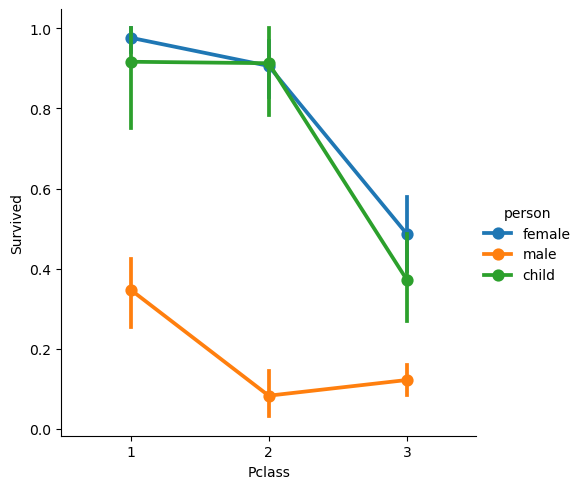

In [62]:
sns.catplot(x='Pclass', y='Survived',hue='person', data=titanic_df,kind='point' )
plt.show()


From the graph above, it is very clear that being a male or being in 3rd class was not very favorable for survival. But even regardless of class, being a male passenger dramatically decreases your chances of survival.

Now, let us see the relation between survival and age

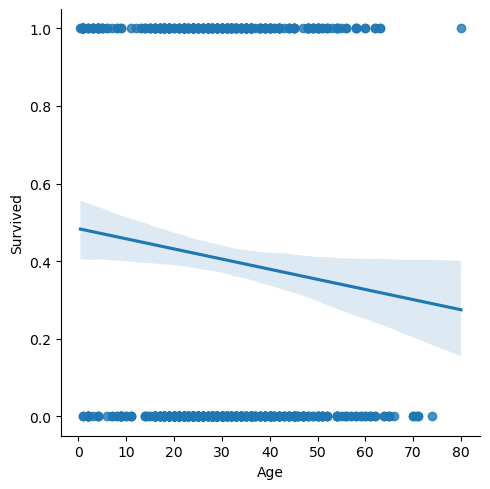

In [66]:
sns.lmplot(x='Age', y='Survived', data=titanic_df)
plt.show()

Analysis: The older you are, the less likely you are to survive.

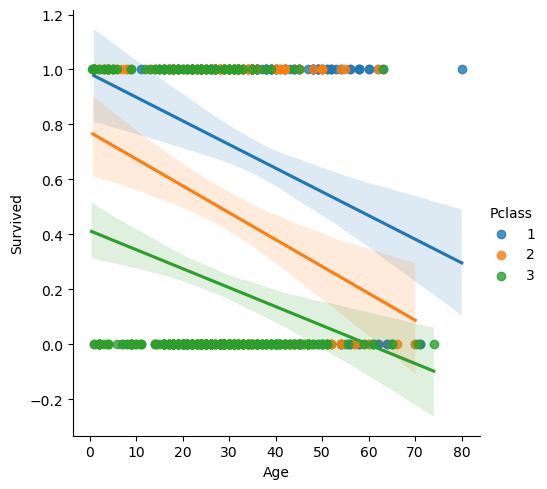

In [68]:
sns.lmplot(x='Age', y='Survived',hue='Pclass', data=titanic_df)
plt.show()

Analysis: First-class passengers and younger individuals had the highest survival rates, while third-class and older passengers were least likely to survive.
To get a clearer picture, we group the ages into bins.

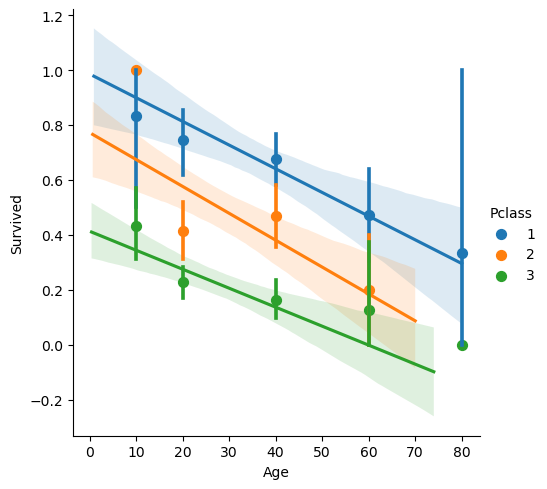

In [71]:
generations=[10,20,40,60,80]
sns.lmplot(x='Age', y='Survived',hue='Pclass', data=titanic_df,x_bins=generations)
plt.show()

Let's now see how gender and age relate to survival trends.

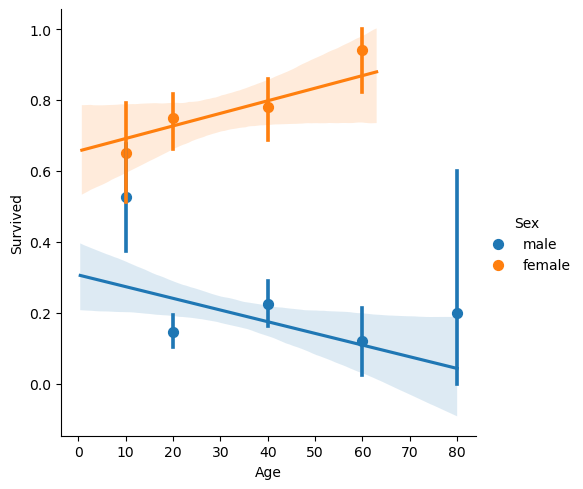

In [74]:
sns.lmplot(x='Age', y='Survived',hue='Sex', data=titanic_df,x_bins=generations)
plt.show()